#Supply chain and Demand Forecasting anomaly Detection

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1)

In [4]:
df = pd.read_csv("retail_store_inventory_cleaned.csv")

In [5]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [6]:
df.tail()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring
73099,2024-01-01,S005,P0020,Groceries,East,117,6,165,2.33,78.39,20,Rainy,1,79.52,Spring


In [7]:
print("Rows and Columns :", df.shape)

Rows and Columns : (73100, 15)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [9]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [10]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')

#Histogram of sales

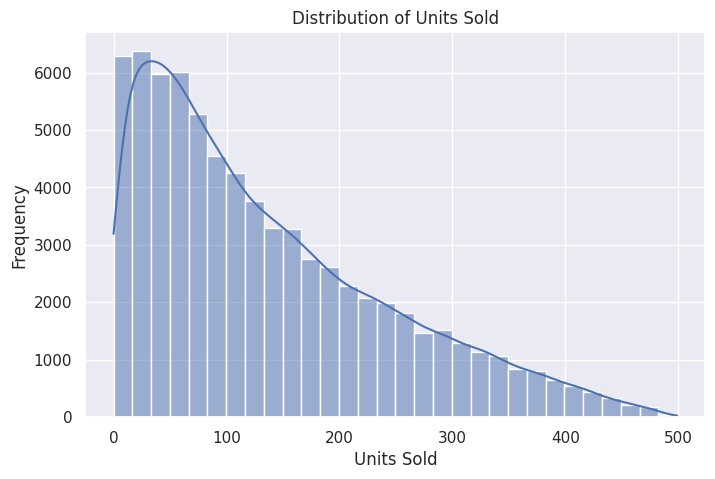

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Units Sold"], bins=30, kde=True)

plt.title("Distribution of Units Sold")

plt.xlabel("Units Sold")

plt.ylabel("Frequency")

plt.show()

#Histogram of  inventory

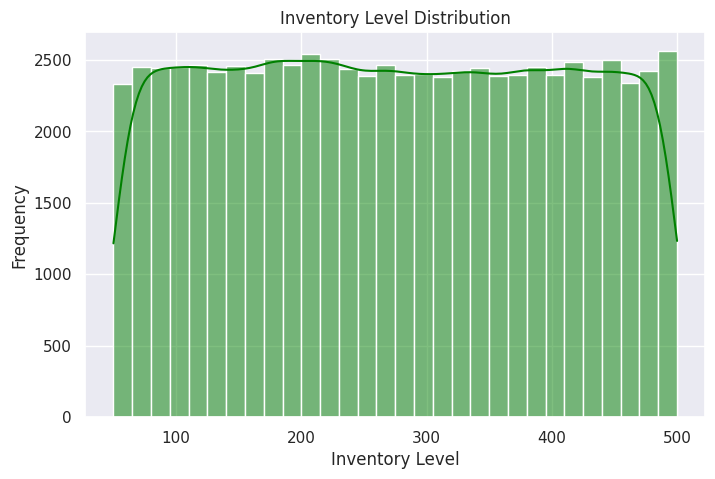

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Inventory Level"], bins=30, color="green", kde=True)

plt.title("Inventory Level Distribution")

plt.xlabel("Inventory Level")

plt.ylabel("Frequency")

plt.show()

#sales Box Plot

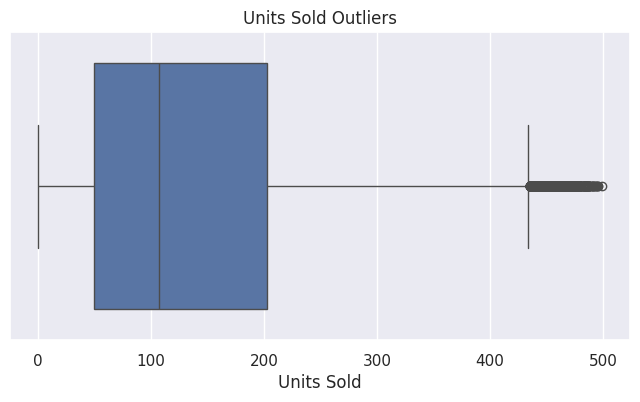

In [13]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Units Sold"])

plt.title("Units Sold Outliers")

plt.show()

#Top 10 Products by Sales

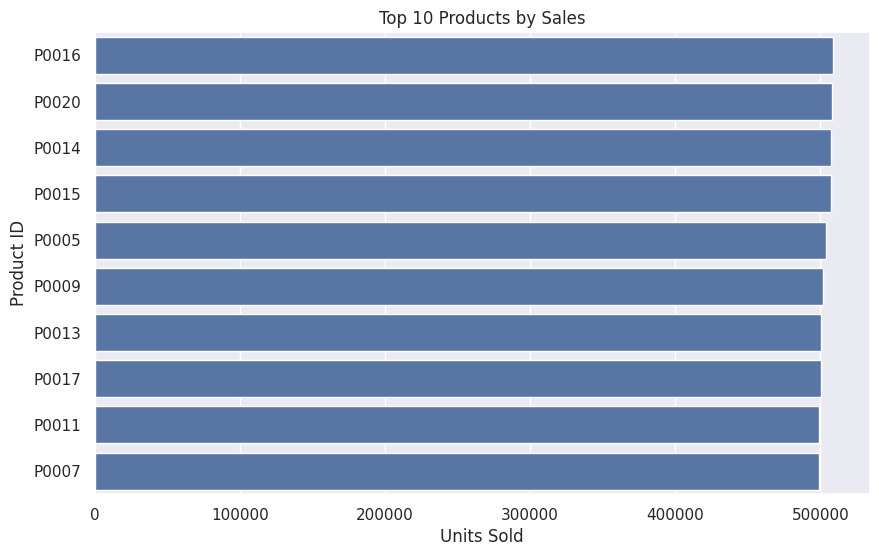

In [14]:
top_products = (
    df.groupby("Product ID")["Units Sold"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")

plt.xlabel("Units Sold")

plt.ylabel("Product ID")

plt.show()

Top 10 Products by Inventory

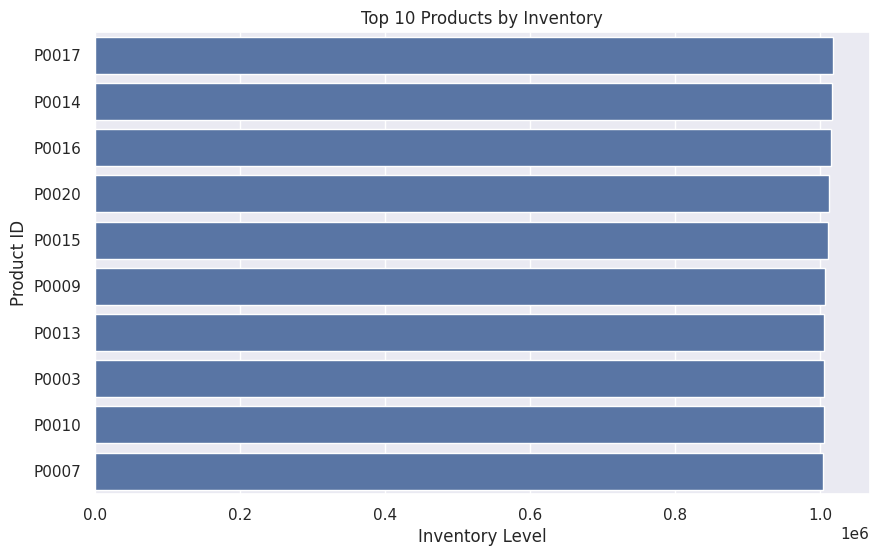

In [15]:
inventory = (
    df.groupby("Product ID")["Inventory Level"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=inventory.values,
    y=inventory.index,
)

plt.title("Top 10 Products by Inventory")

plt.xlabel("Inventory Level")

plt.ylabel("Product ID")

plt.show()

#Product Frequency

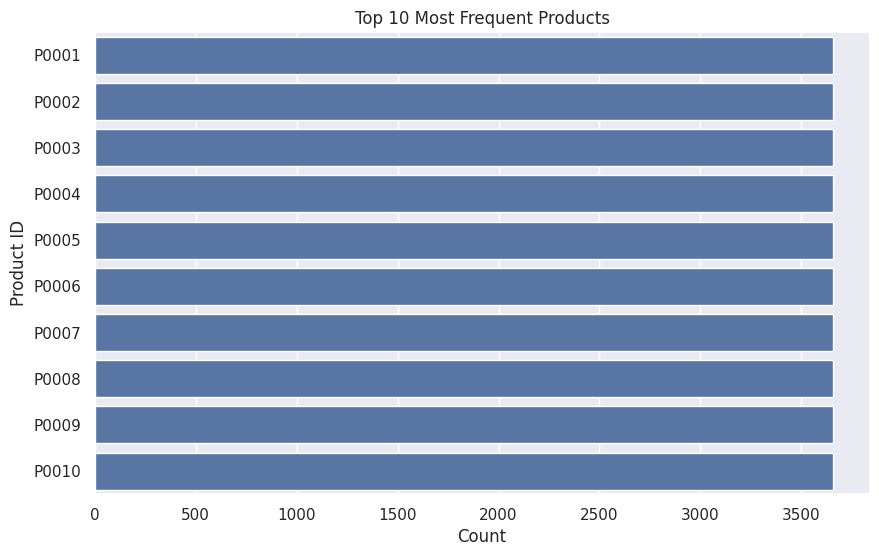

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="Product ID",
    data=df,
    order=df["Product ID"].value_counts().head(10).index
)

plt.title("Top 10 Most Frequent Products")

plt.xlabel("Count")

plt.ylabel("Product ID")

plt.show()

#Category-wise Sales

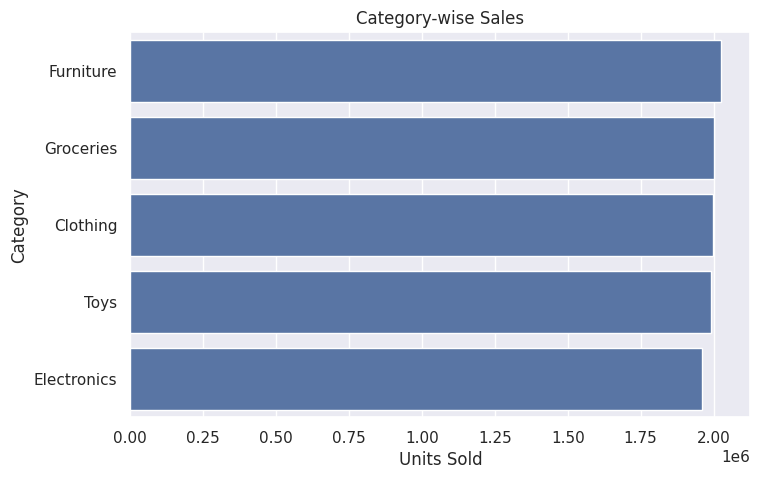

In [17]:
category_sales = (
    df.groupby("Category")["Units Sold"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Category-wise Sales")

plt.xlabel("Units Sold")

plt.ylabel("Category")

plt.show()

In [18]:
df["Date"] = pd.to_datetime(df["Date"])

#Daily Sales Trend

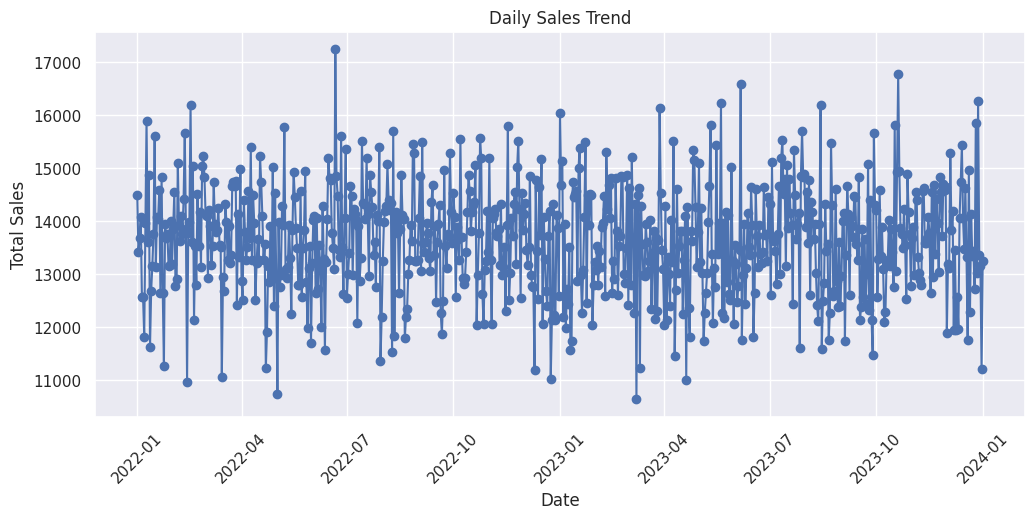

In [19]:
daily_sales = df.groupby("Date")["Units Sold"].sum()
plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values, marker='o')
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#Monthly Sales Trend

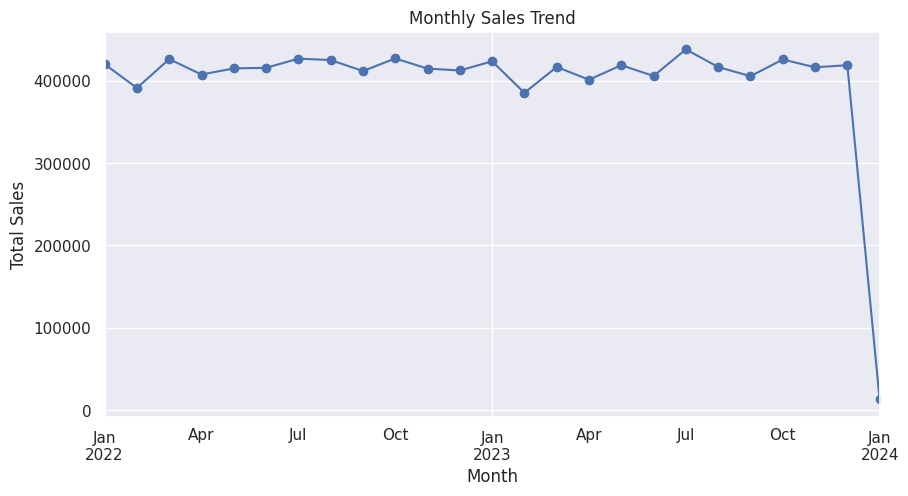

In [20]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Units Sold"].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

#Weekly Sales Trend

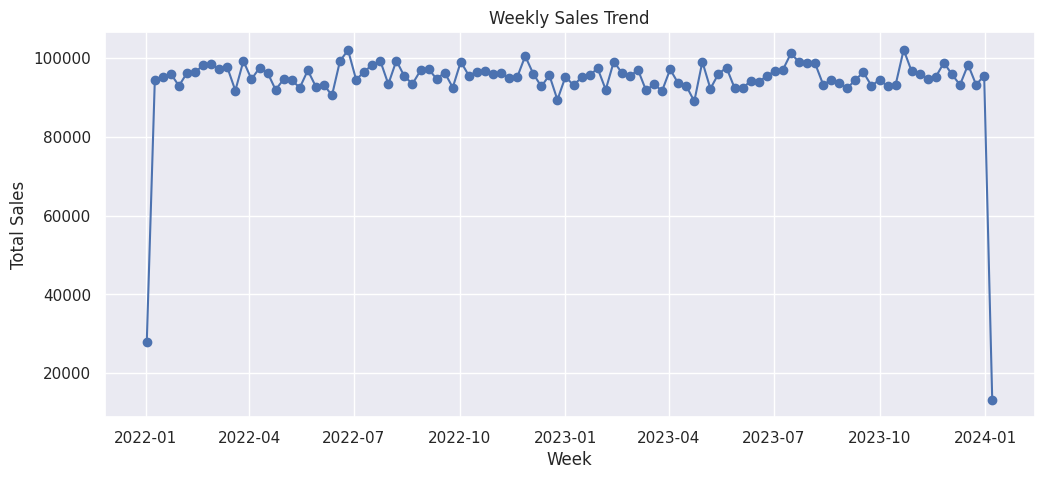

In [21]:
weekly_sales = df.groupby(pd.Grouper(key='Date', freq='W'))['Units Sold'].sum()
plt.figure(figsize=(12,5))
plt.plot(
    weekly_sales.index,
    weekly_sales.values,
    marker='o'
)
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

#Monthly order count

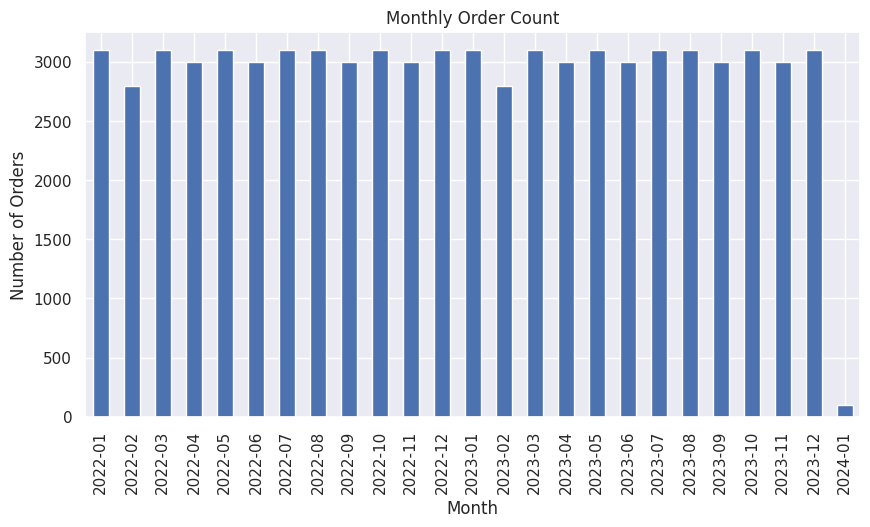

In [22]:
monthly_orders = df.groupby("Month").size()
plt.figure(figsize=(10,5))
monthly_orders.plot(kind="bar")
plt.title("Monthly Order Count")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

#Warehouse wise sales

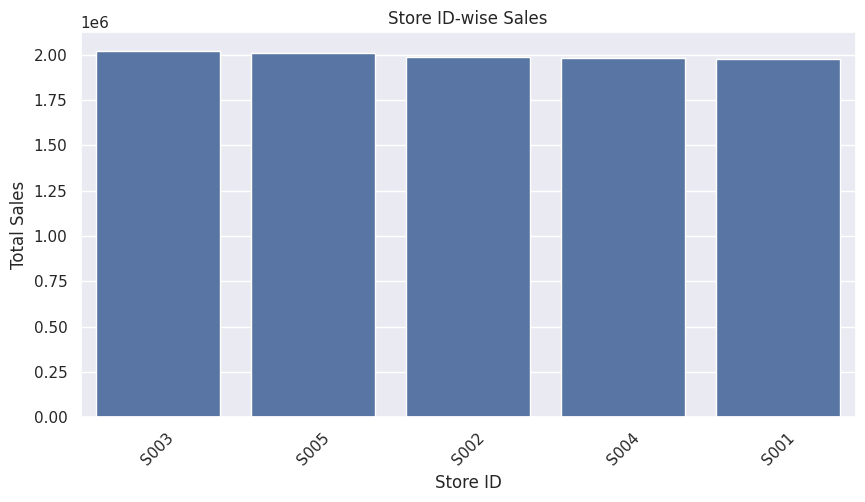

In [23]:
warehouse_sales = (
    df.groupby("Store ID")["Units Sold"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))

sns.barplot(
    x=warehouse_sales.index,
    y=warehouse_sales.values
)
plt.title("Store ID-wise Sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

#Warehouse wise inventory

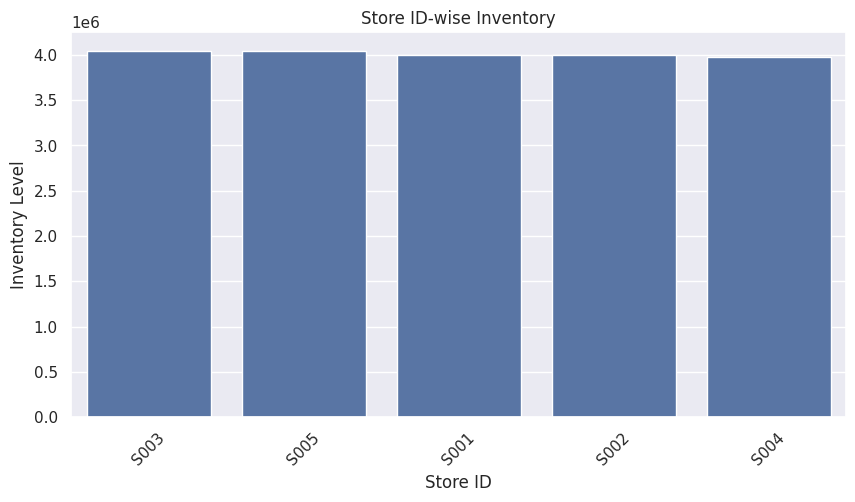

In [24]:
warehouse_inventory = (
    df.groupby("Store ID")["Inventory Level"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))
sns.barplot(
    x=warehouse_inventory.index,
    y=warehouse_inventory.values
)
plt.title("Store ID-wise Inventory")
plt.xlabel("Store ID")
plt.ylabel("Inventory Level")
plt.xticks(rotation=45)
plt.show()

#Inventory vs Sales

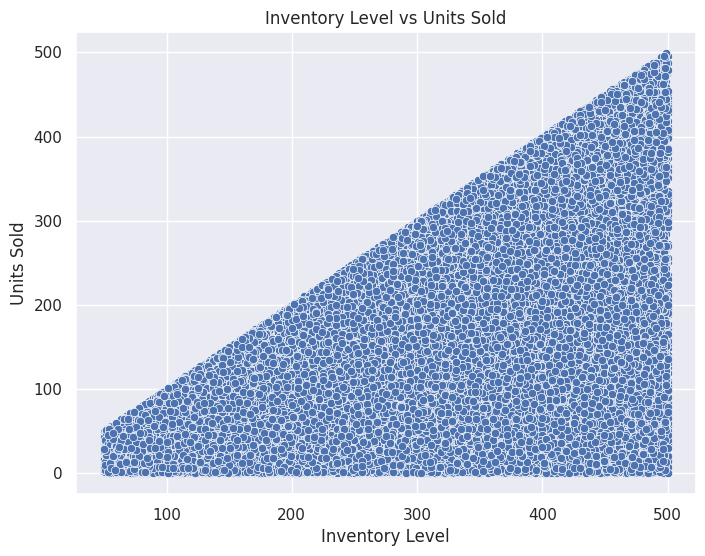

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Inventory Level",
    y="Units Sold"
)
plt.title("Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.show()

#Correlation Heatmap

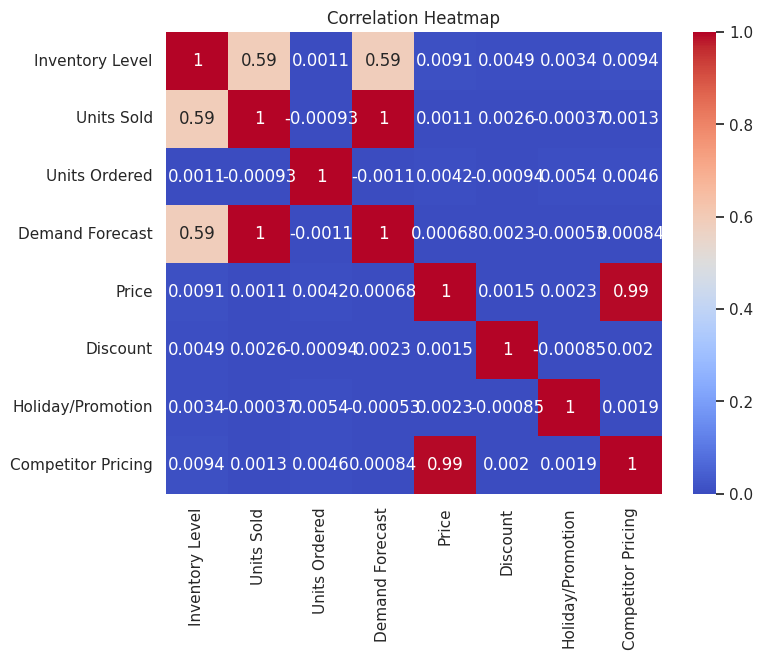

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

#Sales Outlier Detection

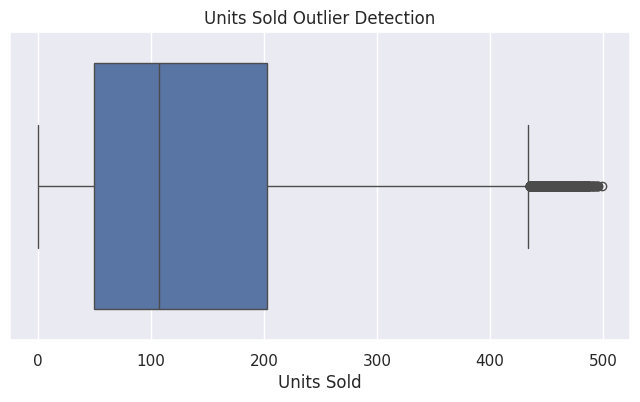

In [27]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Units Sold"])
plt.title("Units Sold Outlier Detection")
plt.show()

In [28]:
df["Units Sold"].describe()

,Units Sold
count,73100.000000
mean,136.464870
std,108.919406
min,0.000000
25%,49.000000
50%,107.000000
75%,203.000000
max,499.000000


#Check sale distribution

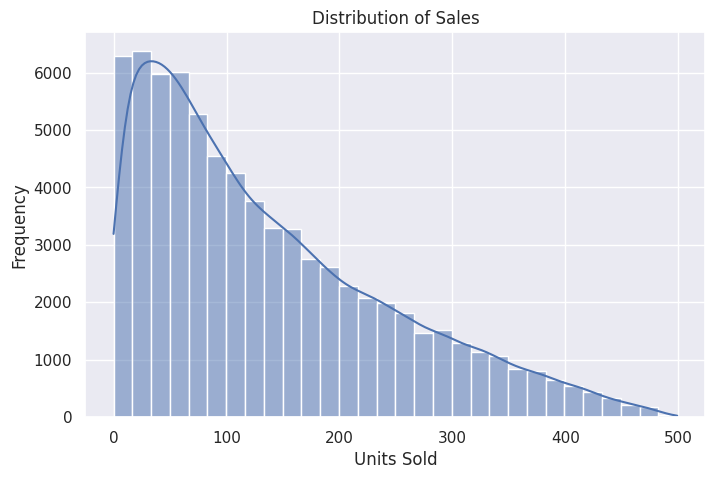

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["Units Sold"], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

#Sales Box-Plot

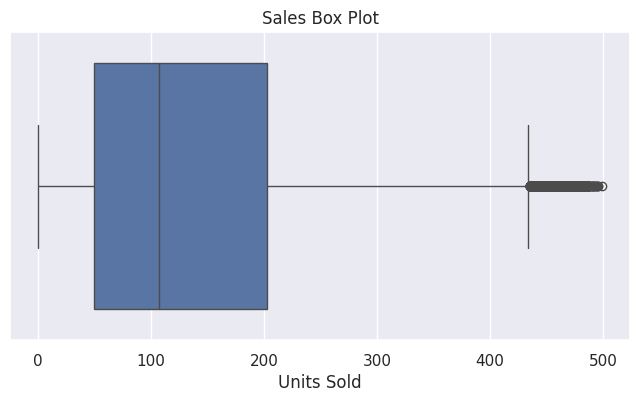

In [30]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Units Sold"])
plt.title("Sales Box Plot")
plt.show()

#Density plot

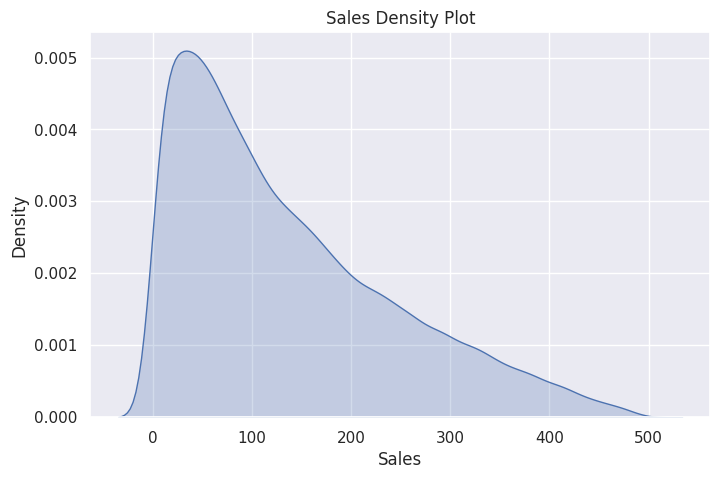

In [31]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["Units Sold"], fill=True)
plt.title("Sales Density Plot")
plt.xlabel("Sales")
plt.show()

#Distribution with Mean Line

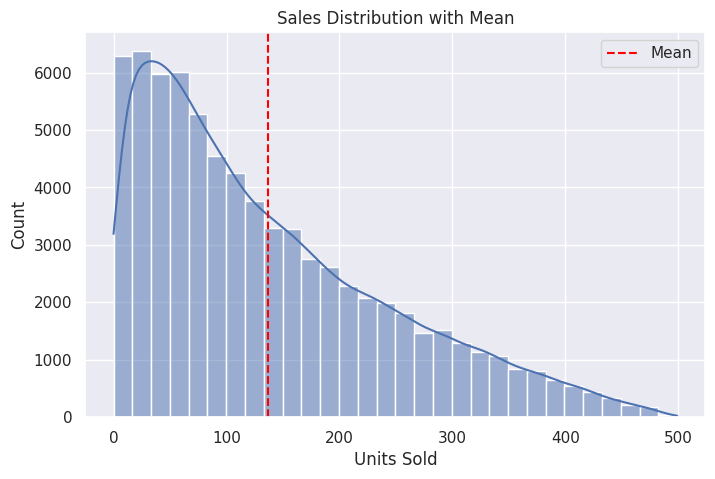

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df["Units Sold"], bins=30, kde=True)
plt.axvline(df["Units Sold"].mean(),
            color="red",
            linestyle="--",
            label="Mean")
plt.legend()
plt.title("Sales Distribution with Mean")
plt.show()

In [33]:
Q1 = df["Units Sold"].quantile(0.25)
Q3 = df["Units Sold"].quantile(0.75)
IQR = Q3 - Q1
print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)

Q1 : 49.0
Q3 : 203.0
IQR : 154.0


In [34]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound :", lower_bound)
print("Upper Bound :", upper_bound)

Lower Bound : -182.0
Upper Bound : 434.0


In [35]:
iqr_anomalies = df[
    (df["Units Sold"] < lower_bound) |
    (df["Units Sold"] > upper_bound)
]
print("Total IQR Anomalies :", len(iqr_anomalies))
iqr_anomalies.head()

Total IQR Anomalies : 715


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Month
102,2022-01-02,S001,P0003,Clothing,South,488,464,163,463.12,70.99,10,Snowy,0,72.93,Summer,2022-01
138,2022-01-02,S002,P0019,Toys,East,492,479,132,469.74,79.11,0,Cloudy,0,80.06,Winter,2022-01
195,2022-01-02,S005,P0016,Groceries,East,487,437,106,432.86,43.64,15,Cloudy,1,39.13,Autumn,2022-01
322,2022-01-04,S002,P0003,Toys,North,493,448,113,459.44,41.55,15,Rainy,0,44.02,Winter,2022-01
554,2022-01-06,S003,P0015,Furniture,North,490,476,53,478.76,20.66,0,Rainy,1,16.87,Winter,2022-01


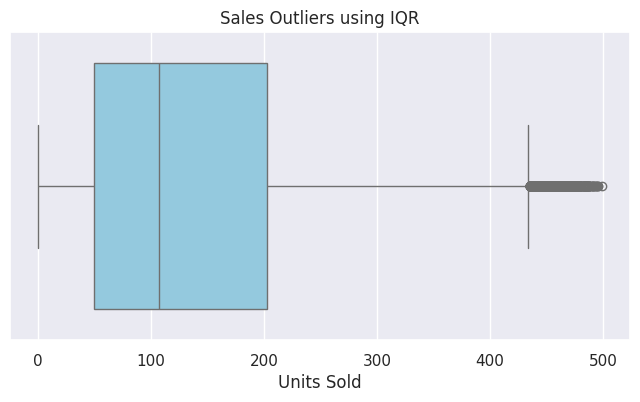

In [36]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Units Sold"], color="skyblue")
plt.title("Sales Outliers using IQR")
plt.show()

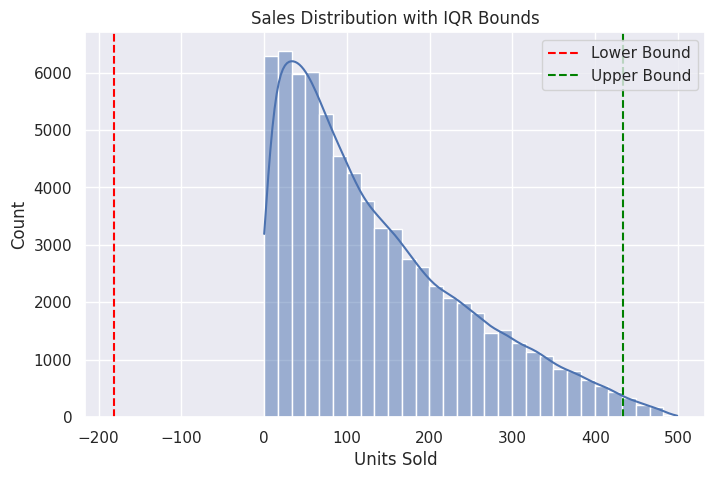

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df["Units Sold"], bins=30, kde=True)
plt.axvline(lower_bound, color="red", linestyle="--", label="Lower Bound")
plt.axvline(upper_bound, color="green", linestyle="--", label="Upper Bound")
plt.legend()
plt.title("Sales Distribution with IQR Bounds")
plt.show()

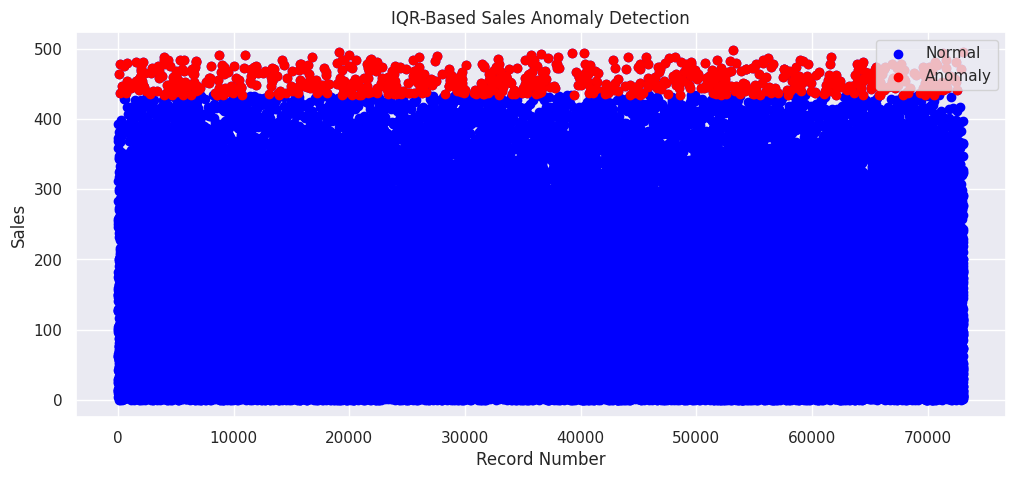

In [38]:
plt.figure(figsize=(12,5))
plt.scatter(df.index,
            df["Units Sold"],
            color="blue",
            label="Normal")
plt.scatter(iqr_anomalies.index,
            iqr_anomalies["Units Sold"],
            color="red",
            label="Anomaly")
plt.title("IQR-Based Sales Anomaly Detection")
plt.xlabel("Record Number")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [39]:
mean_sales = df["Units Sold"].mean()
std_sales = df["Units Sold"].std()
df["Z_score"] = (df["Units Sold"] - mean_sales) / std_sales
anomalies = df[abs(df["Z_score"]) > 3]

print("Z-Score Anomalies :", len(anomalies))
print("IQR Anomalies :", len(iqr_anomalies))

Z-Score Anomalies : 236
IQR Anomalies : 715


#Bar-Chart

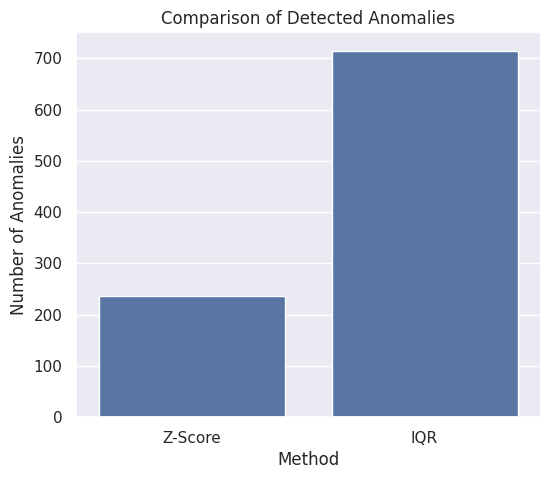

In [40]:
mean_sales = df["Units Sold"].mean()
std_sales = df["Units Sold"].std()
df["Z_score"] = (df["Units Sold"] - mean_sales) / std_sales
anomalies = df[abs(df["Z_score"]) > 3]

methods = ["Z-Score", "IQR"]
counts = [len(anomalies), len(iqr_anomalies)]
plt.figure(figsize=(6,5))
sns.barplot(x=methods, y=counts)
plt.title("Comparison of Detected Anomalies")
plt.xlabel("Method")
plt.ylabel("Number of Anomalies")
plt.show()

#Scatter plot

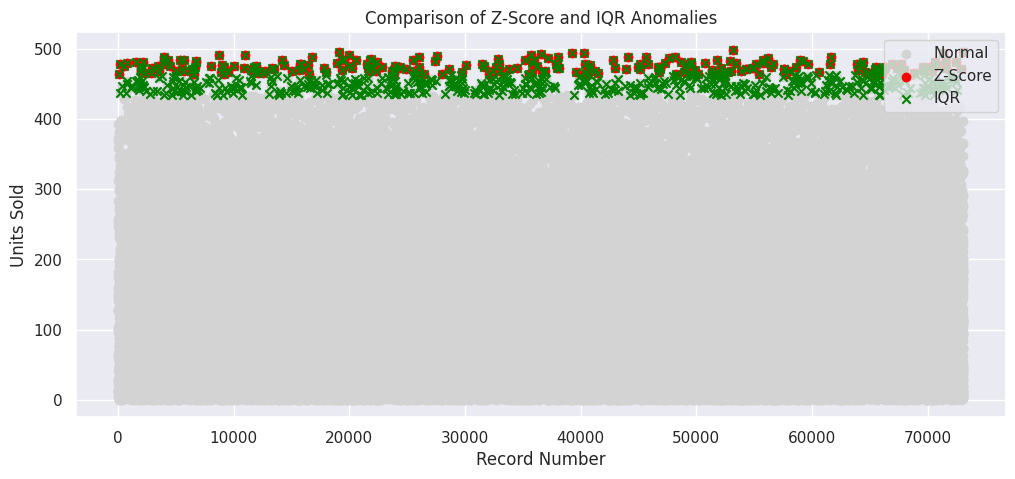

In [41]:
plt.figure(figsize=(12,5))
plt.scatter(df.index,
            df["Units Sold"],
            color="lightgray",
            label="Normal")
plt.scatter(anomalies.index,
            anomalies["Units Sold"],
            color="red",
            label="Z-Score")
plt.scatter(iqr_anomalies.index,
            iqr_anomalies["Units Sold"],
            color="green",
            marker="x",
            label="IQR")
plt.title("Comparison of Z-Score and IQR Anomalies")
plt.xlabel("Record Number")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

#Box-Plot

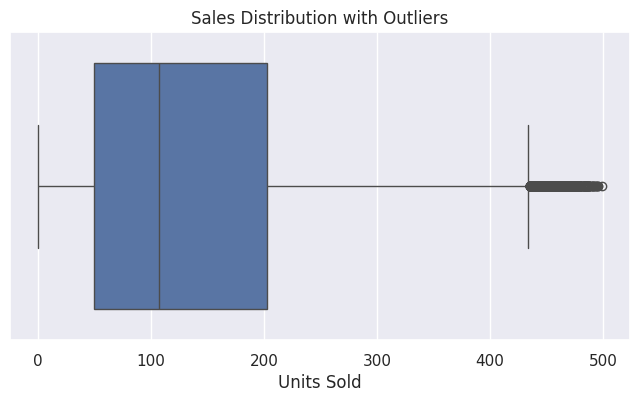

In [42]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Units Sold"])
plt.title("Sales Distribution with Outliers")
plt.show()

#Histogram

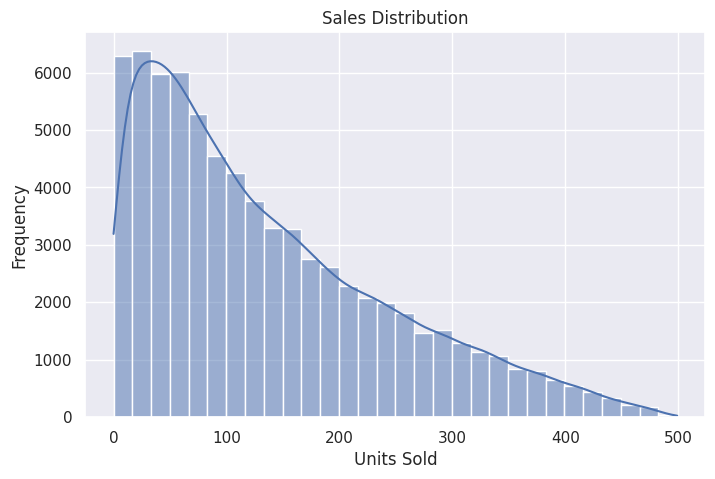

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df["Units Sold"], bins=30, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

#Sales trend with Z-score Anomalies

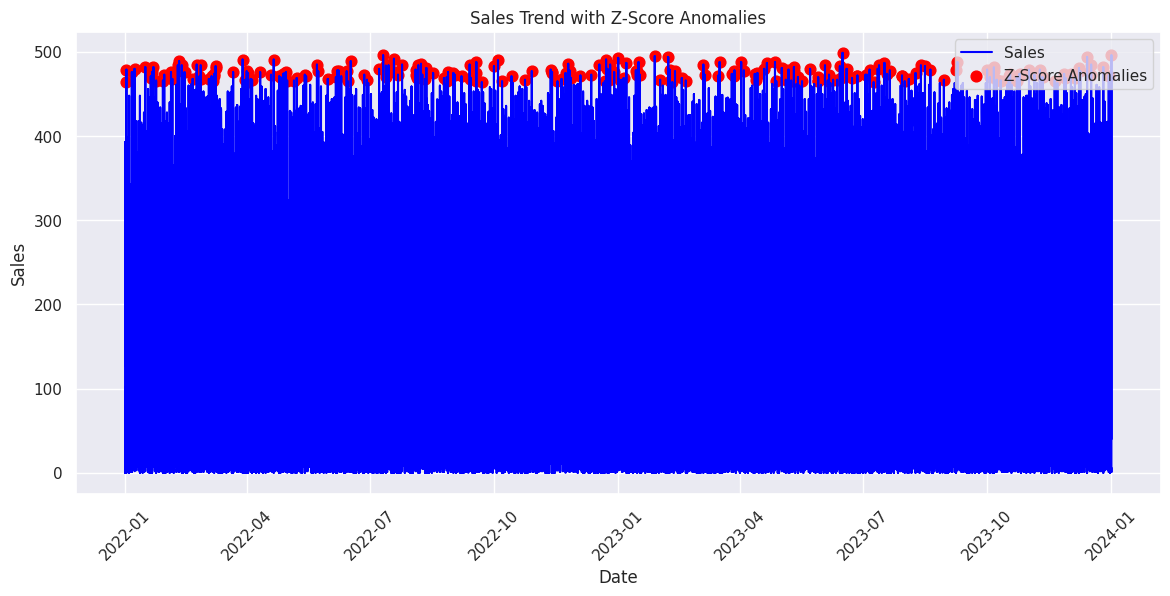

In [44]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Units Sold"], label="Sales", color="blue")
plt.scatter(
    anomalies["Date"],
    anomalies["Units Sold"],
    color="red",
    label="Z-Score Anomalies",
    s=60
)
plt.title("Sales Trend with Z-Score Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()

#Sales trend with IQR Anomalies

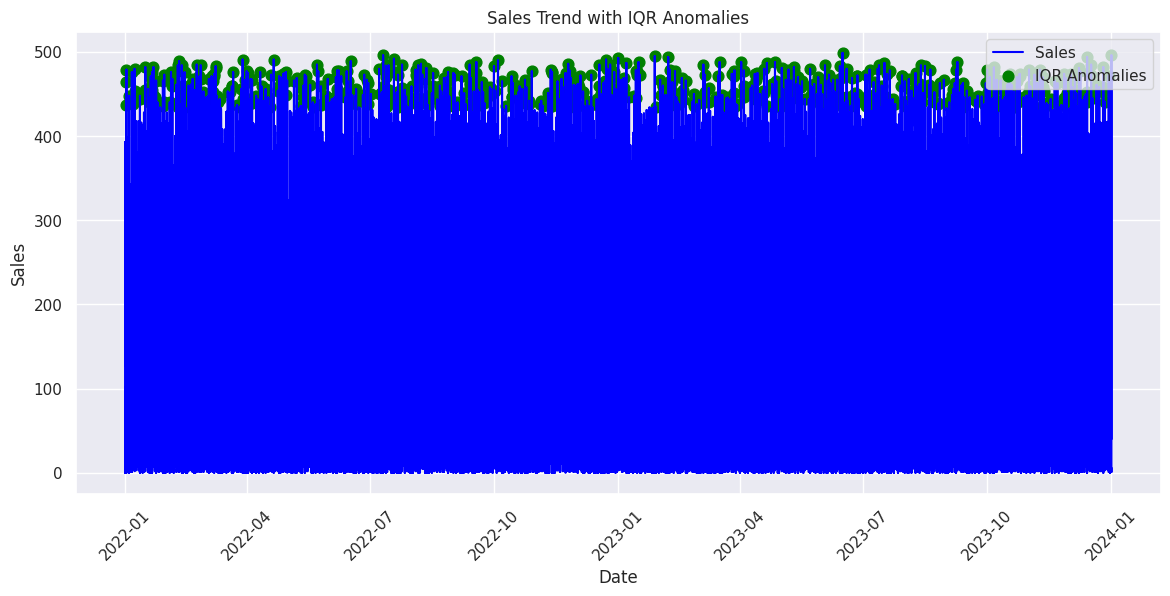

In [45]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Units Sold"], label="Sales", color="blue")
plt.scatter(
    iqr_anomalies["Date"],
    iqr_anomalies["Units Sold"],
    color="green",
    label="IQR Anomalies",
    s=60
)
plt.title("Sales Trend with IQR Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Monthly anomaly count

/tmp/ipykernel_1105/1028101123.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["Month"] = pd.to_datetime(anomalies["Date"]).dt.to_period("M")


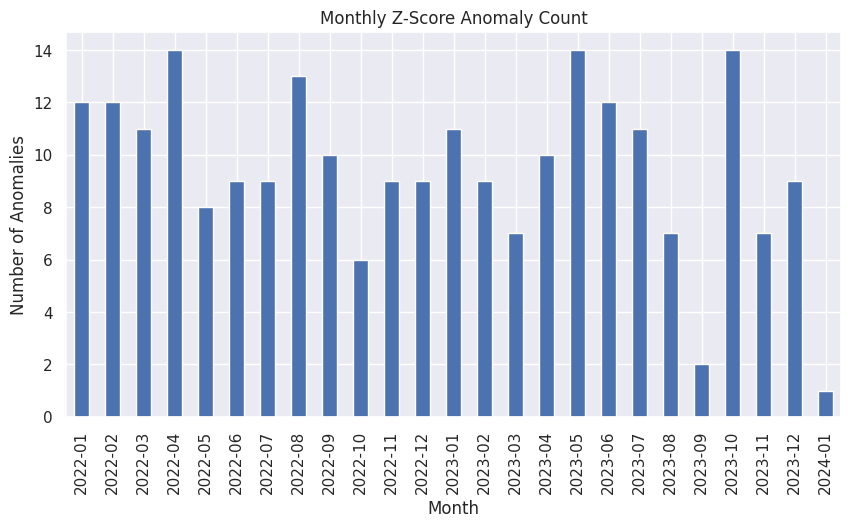

In [46]:
df["Month"] = pd.to_datetime(df["Date"]).dt.to_period("M")
anomalies["Month"] = pd.to_datetime(anomalies["Date"]).dt.to_period("M")
monthly_anomalies = anomalies.groupby("Month").size()
plt.figure(figsize=(10,5))
monthly_anomalies.plot(kind="bar")
plt.title("Monthly Z-Score Anomaly Count")
plt.xlabel("Month")
plt.ylabel("Number of Anomalies")
plt.show()

#Weekly Anomaly Count

/tmp/ipykernel_1105/3996112379.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["Week"] = pd.to_datetime(anomalies["Date"]).dt.isocalendar().week


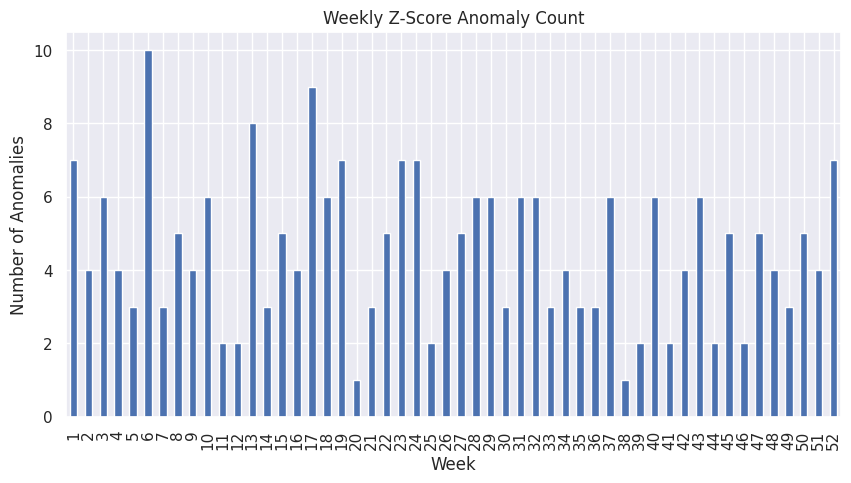

In [47]:
anomalies["Week"] = pd.to_datetime(anomalies["Date"]).dt.isocalendar().week
weekly_anomalies = anomalies.groupby("Week").size()
plt.figure(figsize=(10,5))
weekly_anomalies.plot(kind="bar")
plt.title("Weekly Z-Score Anomaly Count")
plt.xlabel("Week")
plt.ylabel("Number of Anomalies")
plt.show()

In [48]:
summary = pd.DataFrame({
    "Method": ["Z-Score", "IQR"],
    "Anomalies": [len(anomalies), len(iqr_anomalies)]
})
summary

,Method,Anomalies
0,Z-Score,236
1,IQR,715


#Comparision of Anomalies

/tmp/ipykernel_1105/3577083418.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


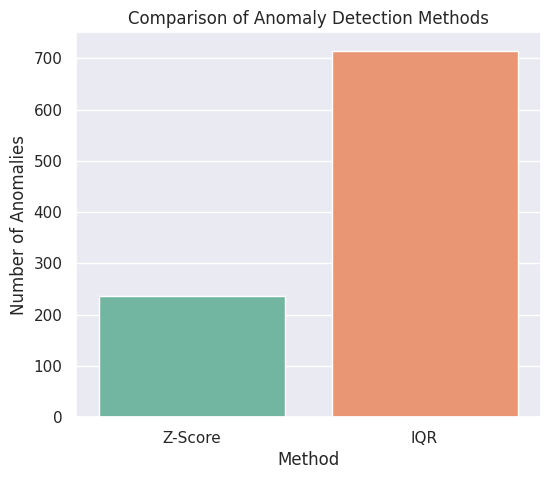

In [49]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=summary,
    x="Method",
    y="Anomalies",
    palette="Set2"
)

plt.title("Comparison of Anomaly Detection Methods")
plt.xlabel("Method")
plt.ylabel("Number of Anomalies")

plt.show()

#Top 10 products with most Anomalies

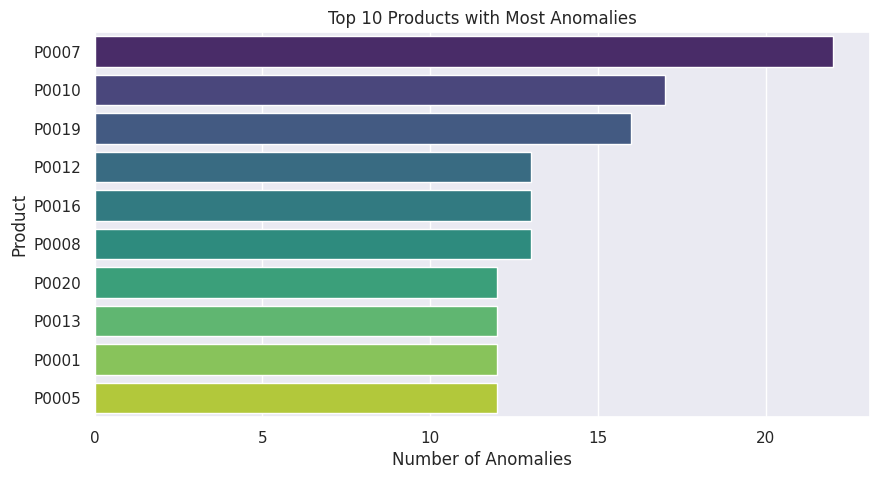

In [50]:
top_products = (
    anomalies["Product ID"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Products with Most Anomalies")
plt.xlabel("Number of Anomalies")
plt.ylabel("Product")

plt.show()

#Monthly Anomaly Trend

/tmp/ipykernel_1105/3955013905.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["Month"] = pd.to_datetime(anomalies["Date"]).dt.to_period("M")


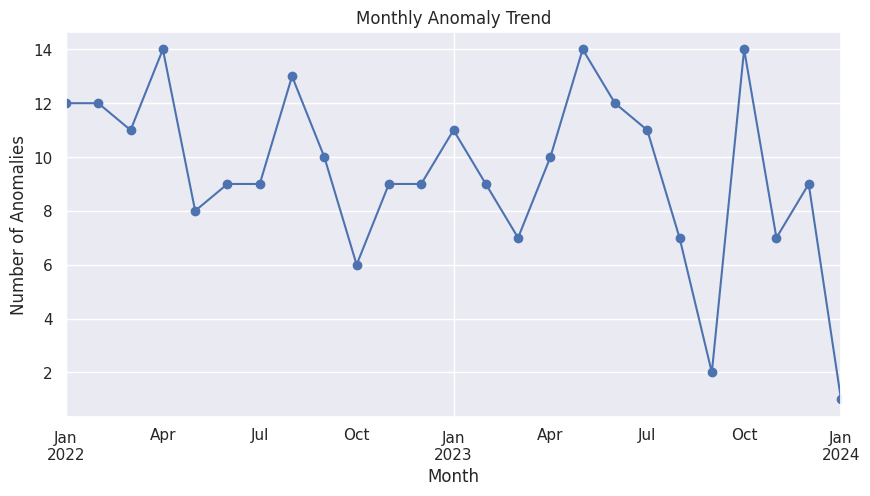

In [51]:
anomalies["Month"] = pd.to_datetime(anomalies["Date"]).dt.to_period("M")

monthly = anomalies.groupby("Month").size()

plt.figure(figsize=(10,5))

monthly.plot(marker="o")

plt.title("Monthly Anomaly Trend")
plt.xlabel("Month")
plt.ylabel("Number of Anomalies")

plt.grid(True)

plt.show()

#Pie chart:Normal vs Anomalies

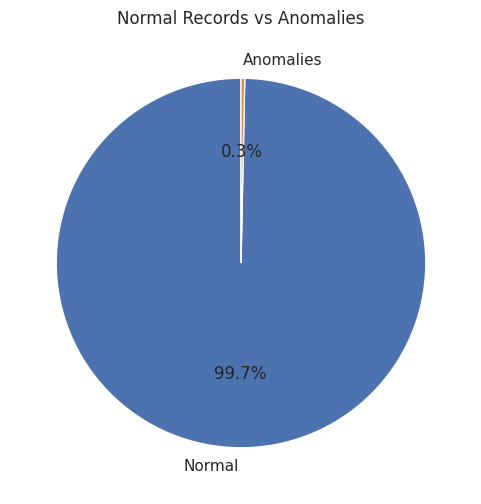

In [52]:
labels = ["Normal", "Anomalies"]

sizes = [
    len(df) - len(anomalies),
    len(anomalies)
]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Normal Records vs Anomalies")

plt.show()

## Business Insights
1.Most sales records fall within the normal range, while only a small number are identified as anomalies.

2.Both Z-Score and IQR methods successfully detected unusual sales patterns, helping identify abnormal transactions.

3.Some products showed repeated anomalies, indicating inconsistent demand or possible inventory management issues.

4.Time-based analysis revealed that anomalies were concentrated during specific periods, suggesting seasonal demand, promotions, or stock shortages.

5.Comparing multiple anomaly detection methods improved confidence in identifying genuine outliers.

#WEEK-3

#Date column check

In [53]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df[["Date", "Units Sold"]].head()

,Date,Units Sold
0,2022-01-01,127
72,2022-01-01,56
71,2022-01-01,9
70,2022-01-01,46
69,2022-01-01,104


#Check the time period

In [54]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 2022-01-01 00:00:00
End Date: 2024-01-01 00:00:00


#Daily Sales EDA

In [55]:
daily_sales = df.groupby("Date")["Units Sold"].sum().reset_index()

daily_sales.describe()

,Date,Units Sold
count,731,731.000000
mean,2023-01-01 00:00:00.000000256,13646.487004
min,2022-01-01 00:00:00,10642.000000
25%,2022-07-02 12:00:00,12981.000000
50%,2023-01-01 00:00:00,13673.000000
75%,2023-07-02 12:00:00,14323.500000
max,2024-01-01 00:00:00,17239.000000
std,NaN,1031.958966


#Daily sales visualization

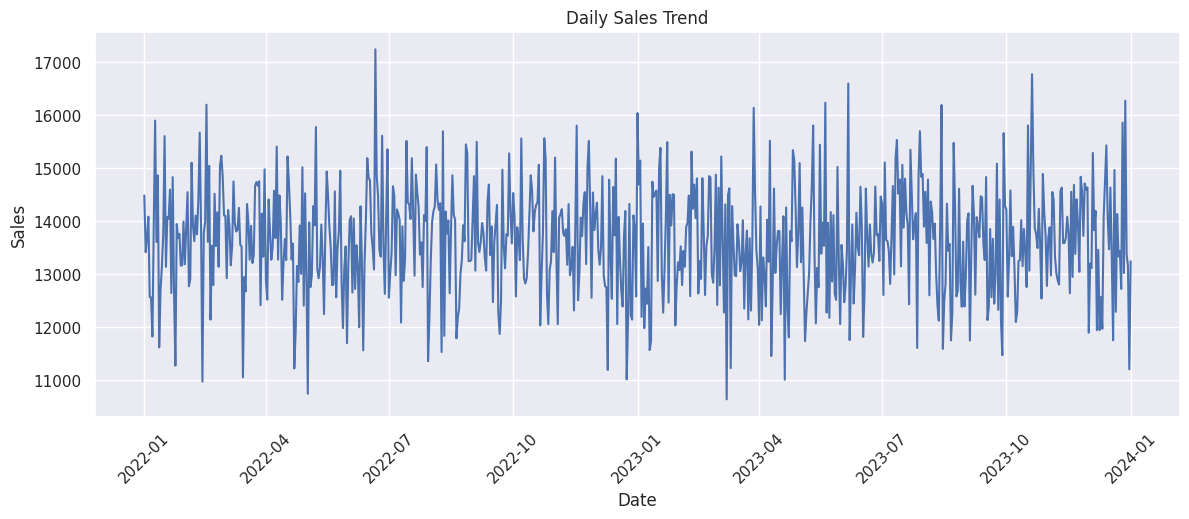

In [56]:
plt.figure(figsize=(14,5))

plt.plot(daily_sales["Date"], daily_sales["Units Sold"])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

#Monthly sales EDA

In [57]:
monthly_sales = (
    daily_sales
    .set_index("Date")["Units Sold"]
    .resample("ME")
    .sum()
    .reset_index()
)

monthly_sales.head()

,Date,Units Sold
0,2022-01-31,419938
1,2022-02-28,391052
2,2022-03-31,426073
3,2022-04-30,407380
4,2022-05-31,414799


#Monthly sasles visualization

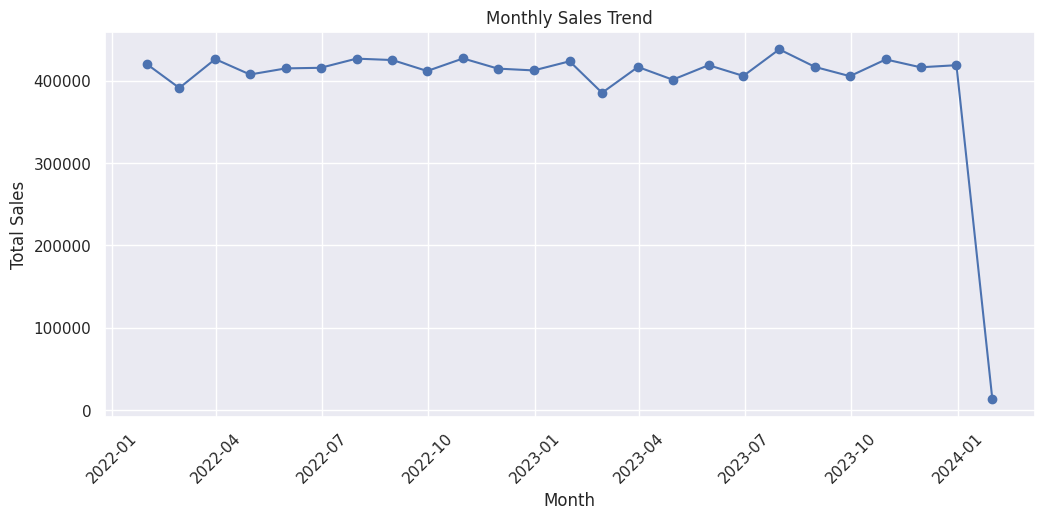

In [58]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Units Sold"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

# Find Lowest and Highest sales

In [59]:
highest = monthly_sales.loc[monthly_sales["Units Sold"].idxmax()]
lowest = monthly_sales.loc[monthly_sales["Units Sold"].idxmin()]

print("Highest Sales Month:")
print(highest)

print("\nLowest Sales Month:")
print(lowest)

Highest Sales Month:
Date          2023-07-31 00:00:00
Units Sold                 437919
Name: 18, dtype: object

Lowest Sales Month:
Date          2024-01-31 00:00:00
Units Sold                  13244
Name: 24, dtype: object


#extract month and year

In [60]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

#Monthly Sales by Month Number

In [61]:
monthly_pattern = df.groupby("Month")["Units Sold"].sum()

print(monthly_pattern)

Month
1     856590
2     776220
3     842595
4     808457
5     833472
6     821150
7     864547
8     841417
9     816971
10    852509
11    830661
12    830993
Name: Units Sold, dtype: int64


#Calculate Average Sales by Month

In [62]:
monthly_avg = df.groupby("Month")["Units Sold"].mean()

print(monthly_avg)

Month
1     135.966667
2     138.610714
3     135.902419
4     134.742833
5     134.430968
6     136.858333
7     139.443065
8     135.712419
9     136.161833
10    137.501452
11    138.443500
12    134.031129
Name: Units Sold, dtype: float64


#Visualize Monthly Sales Pattern

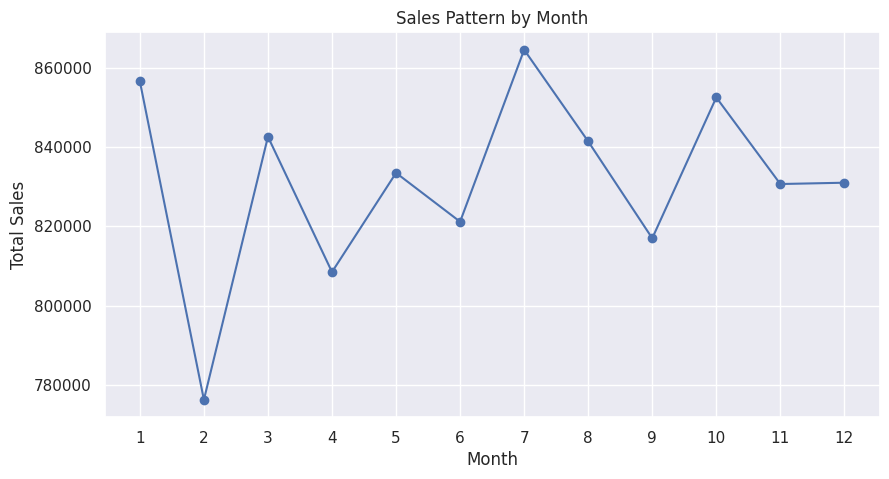

In [63]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o"
)

plt.title("Sales Pattern by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))

plt.show()

#Average Monthly Sales

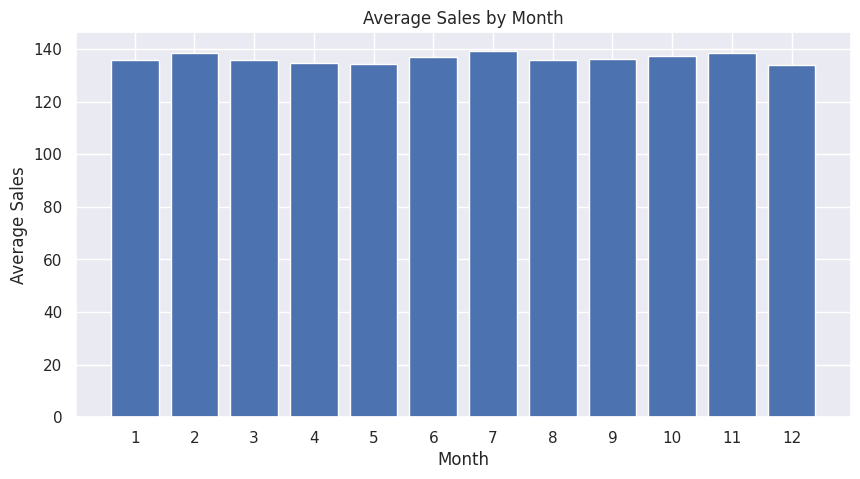

In [64]:
plt.figure(figsize=(10,5))

plt.bar(
    monthly_avg.index,
    monthly_avg.values
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(1, 13))

plt.show()

#Compare Sales Across Years

In [65]:
year_month_sales = df.groupby(
    ["Year", "Month"]
)["Units Sold"].sum().reset_index()

print(year_month_sales.head())

   Year  Month  Units Sold
0  2022      1      419938
1  2022      2      391052
2  2022      3      426073
3  2022      4      407380
4  2022      5      414799


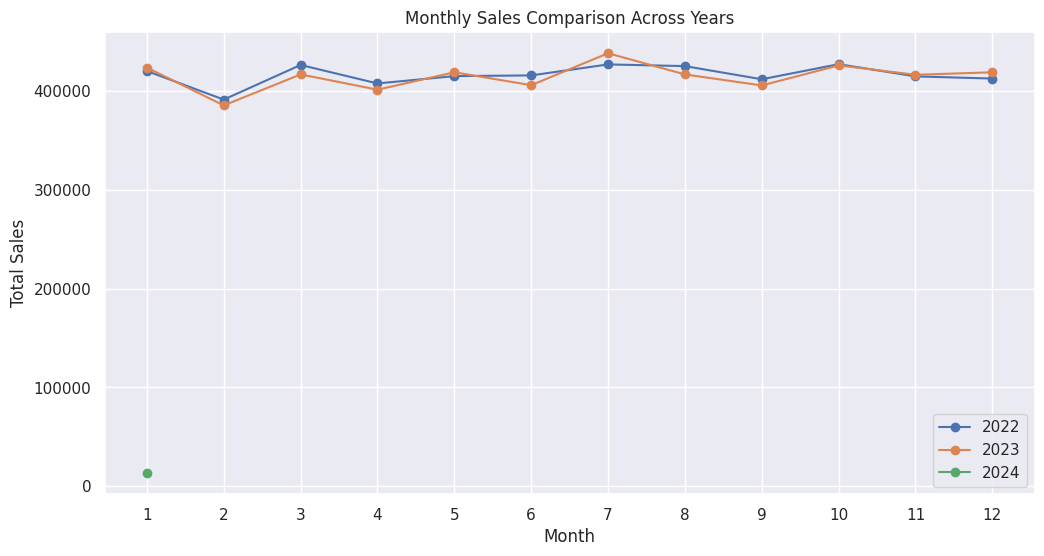

In [66]:
plt.figure(figsize=(12,6))

for year in year_month_sales["Year"].unique():
    data = year_month_sales[
        year_month_sales["Year"] == year
    ]

    plt.plot(
        data["Month"],
        data["Units Sold"],
        marker="o",
        label=str(year)
    )

plt.title("Monthly Sales Comparison Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.legend()

plt.show()

#Create Daily Sales Data

In [70]:
daily_sales = df.groupby("Date")["Units Sold"].sum().reset_index()

daily_sales = daily_sales.sort_values("Date")

#Calculate 7-Day Moving Average

In [74]:
daily_sales["7_Day_MA"] = (
    daily_sales["Units Sold"]
    .rolling(window=7)
    .mean()
)

#Calculate 30-Day Moving Average

In [75]:
daily_sales["30_Day_MA"] = (
    daily_sales["Units Sold"]
    .rolling(window=30)
    .mean()
)

#Check the Data

In [76]:
daily_sales.head(40)

,Date,Units Sold,7_Day_MA,30_Day_MA
0,2022-01-01,14484,NaN,NaN
1,2022-01-02,13415,NaN,NaN
2,2022-01-03,13681,NaN,NaN
3,2022-01-04,14084,NaN,NaN
4,2022-01-05,12572,NaN,NaN
5,2022-01-06,12563,NaN,NaN
6,2022-01-07,11826,13232.142857,NaN
7,2022-01-08,13958,13157.000000,NaN
8,2022-01-09,15896,13511.428571,NaN
9,2022-01-10,13607,13500.857143,NaN


#Actual Sales vs 7-Day Moving Average

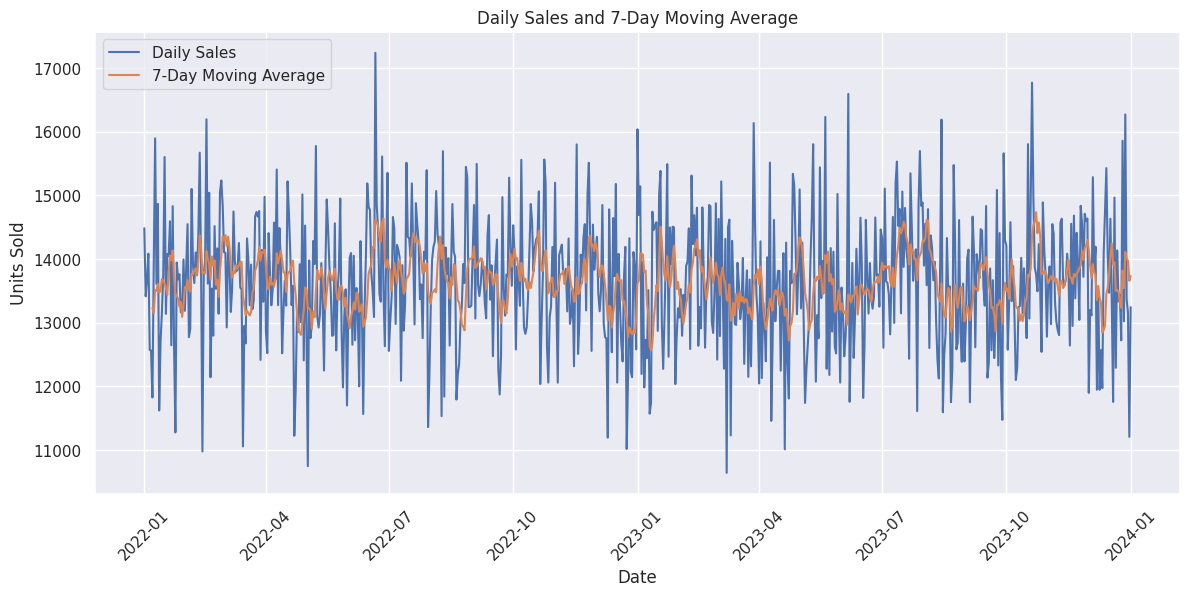

In [78]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Units Sold"],
    label="Daily Sales"
)

plt.plot(
    daily_sales["Date"],
    daily_sales["7_Day_MA"],
    label="7-Day Moving Average"
)

plt.title("Daily Sales and 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)

plt.show()

#30-Day Moving Average

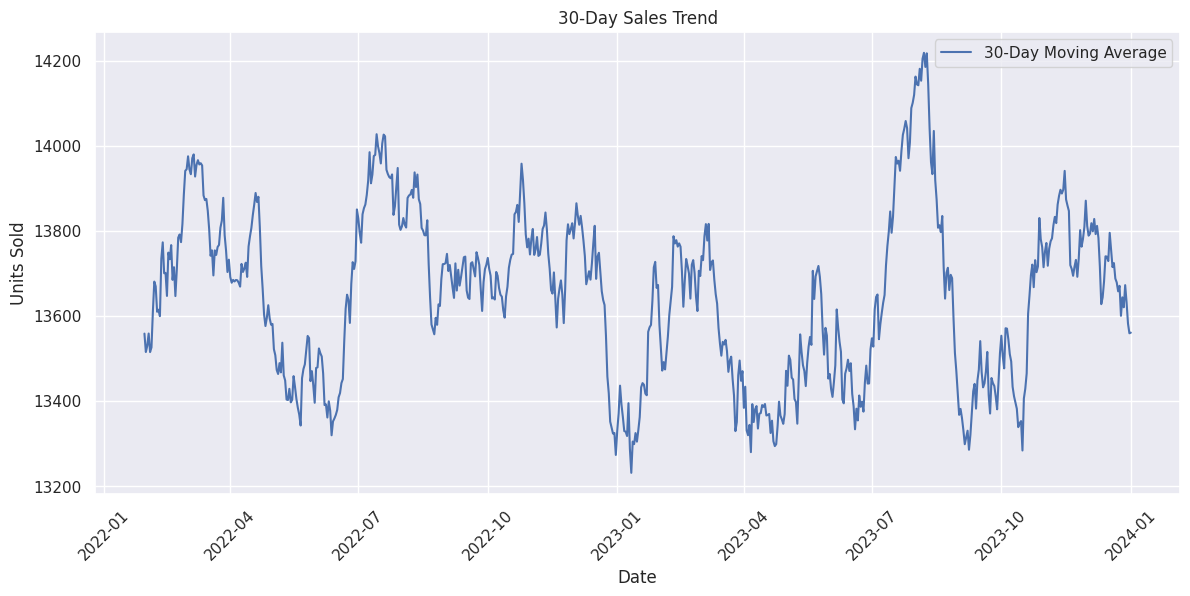

In [79]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["30_Day_MA"],
    label="30-Day Moving Average"
)

plt.title("30-Day Sales Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)

plt.show()

#Find Highest and Lowest Trend Periods

In [80]:
highest_trend = daily_sales.loc[
    daily_sales["30_Day_MA"].idxmax()
]

lowest_trend = daily_sales.loc[
    daily_sales["30_Day_MA"].idxmin()
]

print("Highest 30-Day Average:")
print(highest_trend)

print("\nLowest 30-Day Average:")
print(lowest_trend)

Highest 30-Day Average:
Date          2023-08-07 00:00:00
Units Sold                  14178
7_Day_MA             13996.428571
30_Day_MA            14218.533333
Name: 583, dtype: object

Lowest 30-Day Average:
Date          2023-01-11 00:00:00
Units Sold                  11741
7_Day_MA             12562.285714
30_Day_MA            13231.033333
Name: 375, dtype: object
